# 💳 Credit Card Fraud Detection

---
## 🗂️ Project Structure

This project demonstrates every technique covered during the internship:

| Section | Topic | 
|---------|-------|
| 1 | EDA & Preprocessing |
| 2 | Regression Analysis (Amount Prediction)  |
| 3 | Classification (Supervised Fraud Detection) |
| 4 | Anomaly Detection (Unsupervised)  |
| 5 | Full Comparison & Conclusion  |

> **The Core Challenge:** Only 0.17% of transactions are fraudulent — a severe class imbalance that makes standard accuracy useless. Every modeling choice in this project is shaped by this fact.

## 1. Data Loading, EDA & Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, precision_score,
                             recall_score, mean_absolute_error,
                             mean_squared_error, r2_score)

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


In [2]:
# 1.1  Load Data 
df = pd.read_csv('creditcardfraud/creditcard.csv')

print(f"Shape          : {df.shape}")
print(f"Columns        : {list(df.columns)}")

df.head()

Shape          : (284807, 31)
Columns        : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# 1.2  Missing Values & Basic Stats 
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

print("\n=== Basic Statistics ===")
df.describe().round(3)


=== Missing Values ===
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing: 0

=== Basic Statistics ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,...,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,...,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,88.350,0.002
std,47488.146,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,...,0.735,0.726,0.624,0.606,0.521,0.482,0.404,0.330,250.120,0.042
min,0.000,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,...,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,0.000
25%,54201.500,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,...,-0.228,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,0.000
50%,84692.000,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,...,-0.029,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,0.000
75%,139320.500,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,...,0.186,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.000
max,172792.000,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,...,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000


=== Class Distribution ===
Genuine (0) : 284,315  (99.827%)
Fraud   (1) : 492  (0.173%)

Imbalance ratio: 577:1


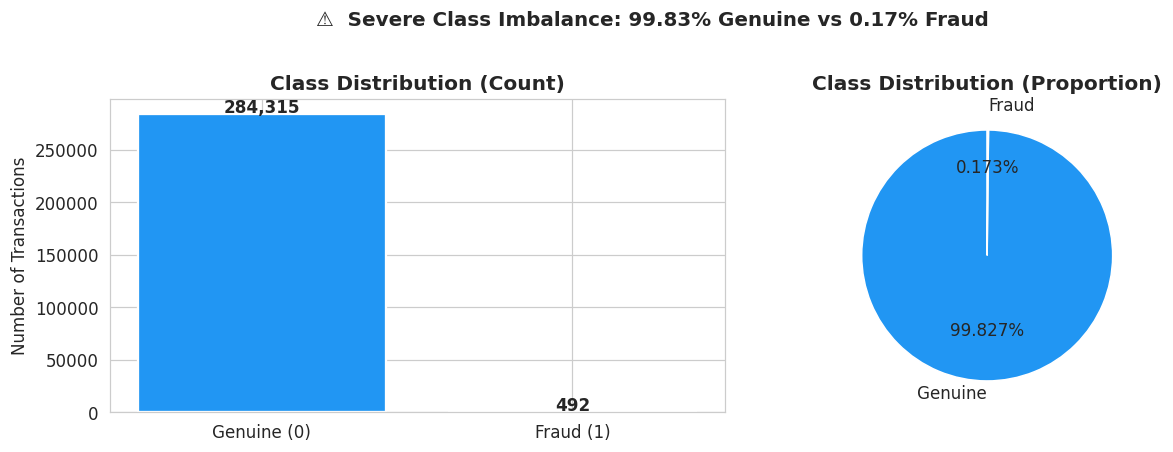

💡 Standard accuracy is meaningless here — a model predicting 'all genuine' scores 99.83%!


In [4]:
# 1.3  Class Distribution 
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

print("=== Class Distribution ===")
print(f"Genuine (0) : {class_counts[0]:,}  ({class_pct[0]:.3f}%)")
print(f"Fraud   (1) : {class_counts[1]:,}  ({class_pct[1]:.3f}%)")
print(f"\nImbalance ratio: {class_counts[0]//class_counts[1]}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Genuine (0)', 'Fraud (1)'], class_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Genuine', 'Fraud'],
            autopct='%1.3f%%', colors=['#2196F3', '#F44336'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (Proportion)', fontweight='bold')

plt.suptitle('⚠️  Severe Class Imbalance: 99.83% Genuine vs 0.17% Fraud',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()
print("💡 Standard accuracy is meaningless here — a model predicting 'all genuine' scores 99.83%!")


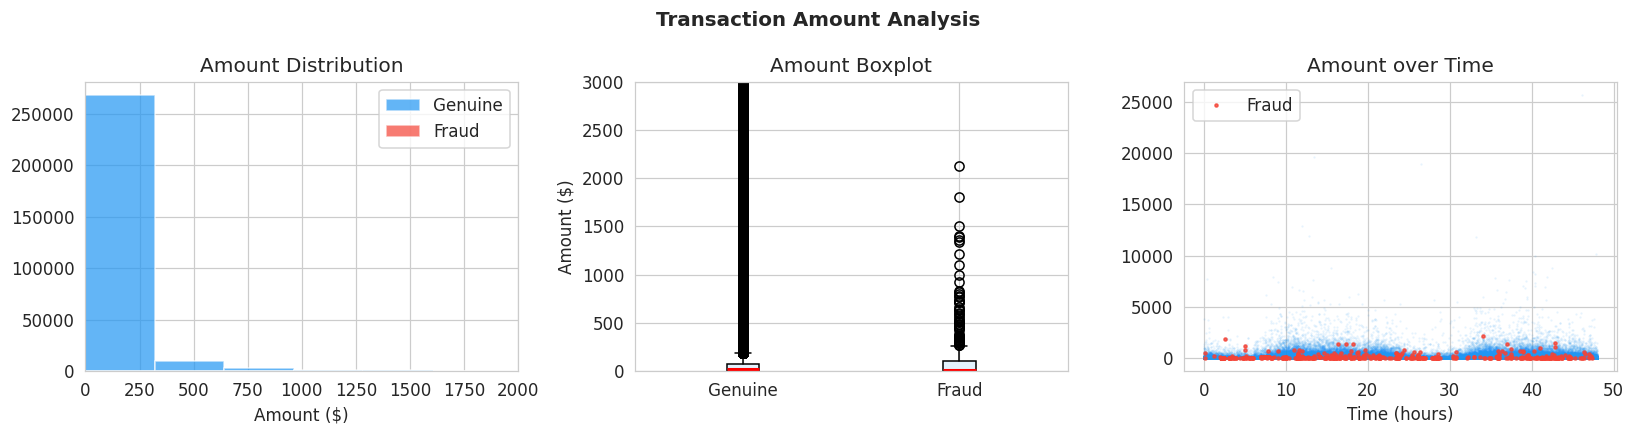

Genuine — Mean: $88.29  |  Median: $22.00  |  Max: $25691.16
Fraud   — Mean: $122.21  |  Median: $9.25  |  Max: $2125.87


In [5]:
# 1.4  Amount Distribution: Fraud vs Genuine 
genuine = df[df['Class'] == 0]['Amount']
fraud   = df[df['Class'] == 1]['Amount']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(genuine, bins=80, color='#2196F3', alpha=0.7, label='Genuine')
axes[0].hist(fraud,   bins=80, color='#F44336', alpha=0.7, label='Fraud')
axes[0].set_title('Amount Distribution')
axes[0].set_xlabel('Amount ($)')
axes[0].legend()
axes[0].set_xlim(0, 2000)

axes[1].boxplot([genuine, fraud], labels=['Genuine', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#E3F2FD'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Amount Boxplot')
axes[1].set_ylabel('Amount ($)')
axes[1].set_ylim(0, 3000)

axes[2].plot(df['Time'] / 3600, df['Amount'], '.', alpha=0.1,
             markersize=1, color='#2196F3')
fraud_pts = df[df['Class'] == 1]
axes[2].plot(fraud_pts['Time'] / 3600, fraud_pts['Amount'], '.',
             color='#F44336', markersize=4, label='Fraud', alpha=0.8)
axes[2].set_title('Amount over Time')
axes[2].set_xlabel('Time (hours)')
axes[2].legend()

plt.suptitle('Transaction Amount Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_amount_analysis.png', bbox_inches='tight')
plt.show()

print(f"Genuine — Mean: ${genuine.mean():.2f}  |  Median: ${genuine.median():.2f}  |  Max: ${genuine.max():.2f}")
print(f"Fraud   — Mean: ${fraud.mean():.2f}  |  Median: ${fraud.median():.2f}  |  Max: ${fraud.max():.2f}")

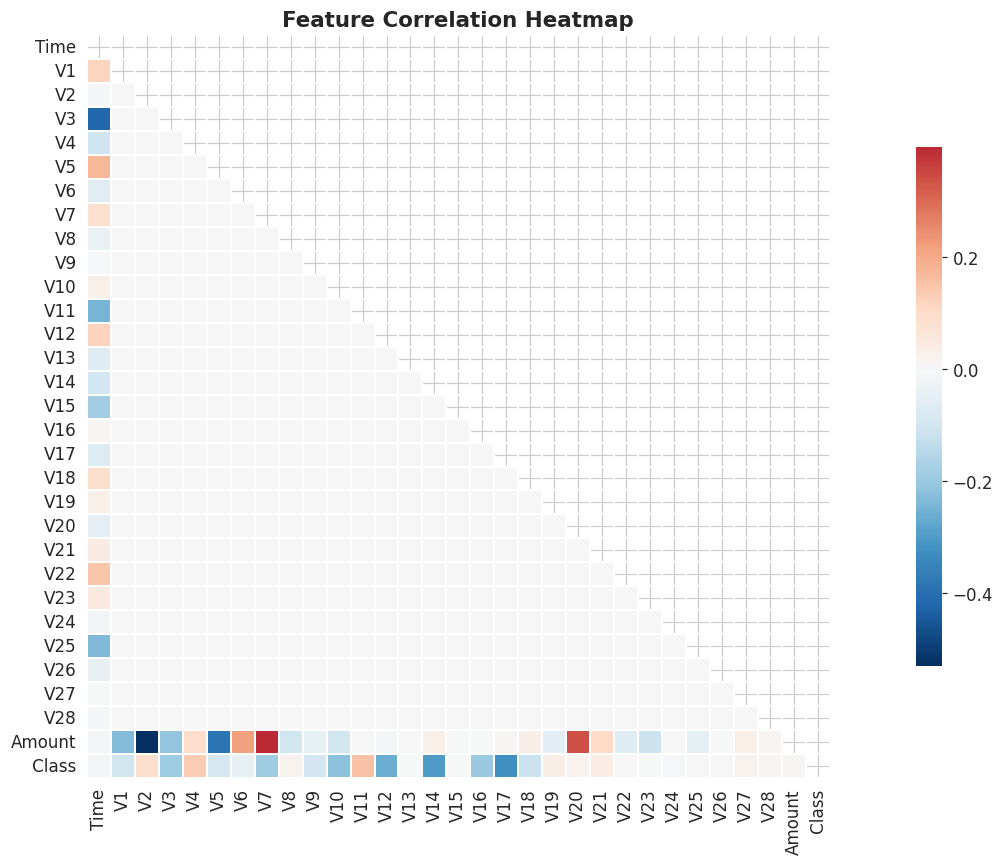

=== Top Features Correlated with Fraud (Class) ===
V17    0.3265
V14    0.3025
V12    0.2606
V10    0.2169
V16    0.1965
V3     0.1930
V7     0.1873
V11    0.1549
V4     0.1334
V18    0.1115
Name: Class, dtype: float64


In [6]:
# 1.5  Correlation Heatmap 
plt.figure(figsize=(16, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.7},
            annot=False)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlations with Class
print("=== Top Features Correlated with Fraud (Class) ===")
class_corr = corr['Class'].drop('Class').abs().sort_values(ascending=False)
print(class_corr.head(10).round(4))

In [7]:
# 1.6  Preprocessing: Scale Amount & Time 
df_processed = df.copy()

scaler = StandardScaler()
df_processed['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df_processed['Time_scaled']   = scaler.fit_transform(df[['Time']])

# Drop original unscaled columns
df_processed.drop(['Amount', 'Time'], axis=1, inplace=True)

print("✅ Amount and Time scaled with StandardScaler")
print(f"   Amount_scaled — mean: {df_processed['Amount_scaled'].mean():.4f}  std: {df_processed['Amount_scaled'].std():.4f}")
print(f"   Time_scaled   — mean: {df_processed['Time_scaled'].mean():.4f}  std: {df_processed['Time_scaled'].std():.4f}")
print(f"\nFinal feature set: {df_processed.shape[1] - 1} features + 1 target")

✅ Amount and Time scaled with StandardScaler
   Amount_scaled — mean: 0.0000  std: 1.0000
   Time_scaled   — mean: -0.0000  std: 1.0000

Final feature set: 30 features + 1 target


In [8]:
# 1.7  Train / Test Split
X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

# stratify=y ensures same fraud ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("=== Train / Test Split (80/20, stratified) ===")
print(f"X_train: {X_train.shape}  |  y_train fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"X_test : {X_test.shape}  |  y_test  fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)")
print("\n✅ stratify=y preserves the fraud ratio in both splits")

=== Train / Test Split (80/20, stratified) ===
X_train: (227845, 30)  |  y_train fraud: 394 (0.173%)
X_test : (56962, 30)  |  y_test  fraud: 98 (0.172%)

✅ stratify=y preserves the fraud ratio in both splits


## 2. Regression Analysis: Predicting Transaction Amount

**Why regression on a fraud dataset?**  
We predict `Amount` from the V1–V28 features. Because fraudulent transactions have unusual patterns, the model will make larger errors (residuals) on fraud cases. High residuals = potential anomaly signal.


In [9]:
# 2.1  Setup for Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Use original df for regression (Amount is the target here)
X_reg = df[['V' + str(i) for i in range(1, 29)]]
y_reg = df['Amount']

X_reg_train, X_reg_test, y_reg_train, y_reg_test, class_train, class_test = train_test_split(
    X_reg, y_reg, df['Class'], test_size=0.2, random_state=42, stratify=df['Class'])

# Scale features for regression
scaler_reg = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_test_sc  = scaler_reg.transform(X_reg_test)

print("✅ Regression data prepared")
print(f"   Features: {X_reg.shape[1]} (V1–V28)")
print(f"   Target:   Amount ($)")

✅ Regression data prepared
   Features: 28 (V1–V28)
   Target:   Amount ($)


In [10]:
# 2.2  Simple Linear Regression (best single feature)
# Find the feature most correlated with Amount
correlations = df[['V' + str(i) for i in range(1,29)]].corrwith(df['Amount']).abs()
best_feature  = correlations.idxmax()
print(f"Best single feature correlated with Amount: {best_feature} (r={correlations.max():.4f})")

X_simple = df[[best_feature]].values
scaler_simple = StandardScaler()
X_simple_sc = scaler_simple.fit_transform(X_simple)

X_s_train, X_s_test, y_s_train, y_s_test, cls_s_train, cls_s_test = train_test_split(
    X_simple_sc, y_reg, df['Class'], test_size=0.2, random_state=42, stratify=df['Class'])

slr = LinearRegression()
slr.fit(X_s_train, y_s_train)
pred_slr = slr.predict(X_s_test)

mae_slr  = mean_absolute_error(y_s_test, pred_slr)
rmse_slr = np.sqrt(mean_squared_error(y_s_test, pred_slr))
r2_slr   = r2_score(y_s_test, pred_slr)

print(f"\n=== Simple Linear Regression ({best_feature} → Amount) ===")
print(f"  MAE : ${mae_slr:.2f}")
print(f"  RMSE: ${rmse_slr:.2f}")
print(f"  R²  : {r2_slr:.4f}")
print(f"  β₀={slr.intercept_:.4f}  β₁={slr.coef_[0]:.4f}")


Best single feature correlated with Amount: V2 (r=0.5314)

=== Simple Linear Regression (V2 → Amount) ===
  MAE : $97.95
  RMSE: $209.02
  R²  : 0.2879
  β₀=88.1375  β₁=-133.0972


In [11]:
# 2.3  Multiple Linear Regression (all V features)
mlr = LinearRegression()
mlr.fit(X_reg_train_sc, y_reg_train)
pred_mlr = mlr.predict(X_reg_test_sc)

mae_mlr  = mean_absolute_error(y_reg_test, pred_mlr)
rmse_mlr = np.sqrt(mean_squared_error(y_reg_test, pred_mlr))
r2_mlr   = r2_score(y_reg_test, pred_mlr)

print("=== Multiple Linear Regression (28 features → Amount) ===")
print(f"  MAE : ${mae_mlr:.2f}")
print(f"  RMSE: ${rmse_mlr:.2f}")
print(f"  R²  : {r2_mlr:.4f}")


=== Multiple Linear Regression (28 features → Amount) ===
  MAE : $24.16
  RMSE: $67.68
  R²  : 0.9254


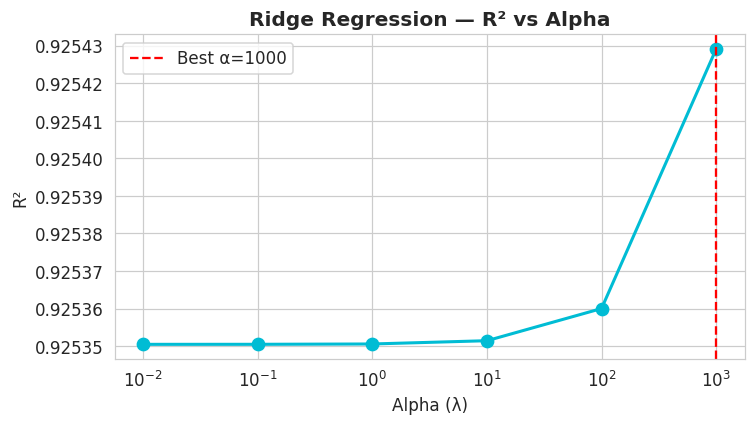

Best alpha: 1000
  MAE : $24.31  |  RMSE: $67.64  |  R²: 0.9254


In [12]:
# 2.4  Ridge Regression
from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge_r2 = []
for a in alphas:
    r = Ridge(alpha=a)
    r.fit(X_reg_train_sc, y_reg_train)
    ridge_r2.append(r2_score(y_reg_test, r.predict(X_reg_test_sc)))

best_alpha_ridge = alphas[np.argmax(ridge_r2)]
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_reg_train_sc, y_reg_train)
pred_ridge = ridge.predict(X_reg_test_sc)

mae_ridge  = mean_absolute_error(y_reg_test, pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_reg_test, pred_ridge))
r2_ridge   = r2_score(y_reg_test, pred_ridge)

# Plot alpha search
plt.figure(figsize=(7, 4))
plt.semilogx(alphas, ridge_r2, 'o-', color='#00BCD4', linewidth=2, markersize=8)
plt.axvline(best_alpha_ridge, color='red', linestyle='--', label=f'Best α={best_alpha_ridge}')
plt.xlabel('Alpha (λ)')
plt.ylabel('R²')
plt.title('Ridge Regression — R² vs Alpha', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('fig4_ridge_alpha.png', bbox_inches='tight')
plt.show()

print(f"Best alpha: {best_alpha_ridge}")
print(f"  MAE : ${mae_ridge:.2f}  |  RMSE: ${rmse_ridge:.2f}  |  R²: {r2_ridge:.4f}")

In [13]:
# 2.5  Lasso Regression
from sklearn.linear_model import Lasso

lasso_r2 = []
lasso_zeros = []
for a in alphas:
    l = Lasso(alpha=a, max_iter=5000)
    l.fit(X_reg_train_sc, y_reg_train)
    lasso_r2.append(r2_score(y_reg_test, l.predict(X_reg_test_sc)))
    lasso_zeros.append(np.sum(l.coef_ == 0))

best_alpha_lasso = alphas[np.argmax(lasso_r2)]
lasso = Lasso(alpha=best_alpha_lasso, max_iter=5000)
lasso.fit(X_reg_train_sc, y_reg_train)
pred_lasso = lasso.predict(X_reg_test_sc)

mae_lasso  = mean_absolute_error(y_reg_test, pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_reg_test, pred_lasso))
r2_lasso   = r2_score(y_reg_test, pred_lasso)

eliminated = X_reg.columns[lasso.coef_ == 0].tolist()
print(f"Best alpha: {best_alpha_lasso}")
print(f"  MAE : ${mae_lasso:.2f}  |  RMSE: ${rmse_lasso:.2f}  |  R²: {r2_lasso:.4f}")
print(f"  Features eliminated (β=0): {len(eliminated)} → {eliminated}")

Best alpha: 0.1
  MAE : $24.20  |  RMSE: $67.66  |  R²: 0.9254
  Features eliminated (β=0): 1 → ['V11']


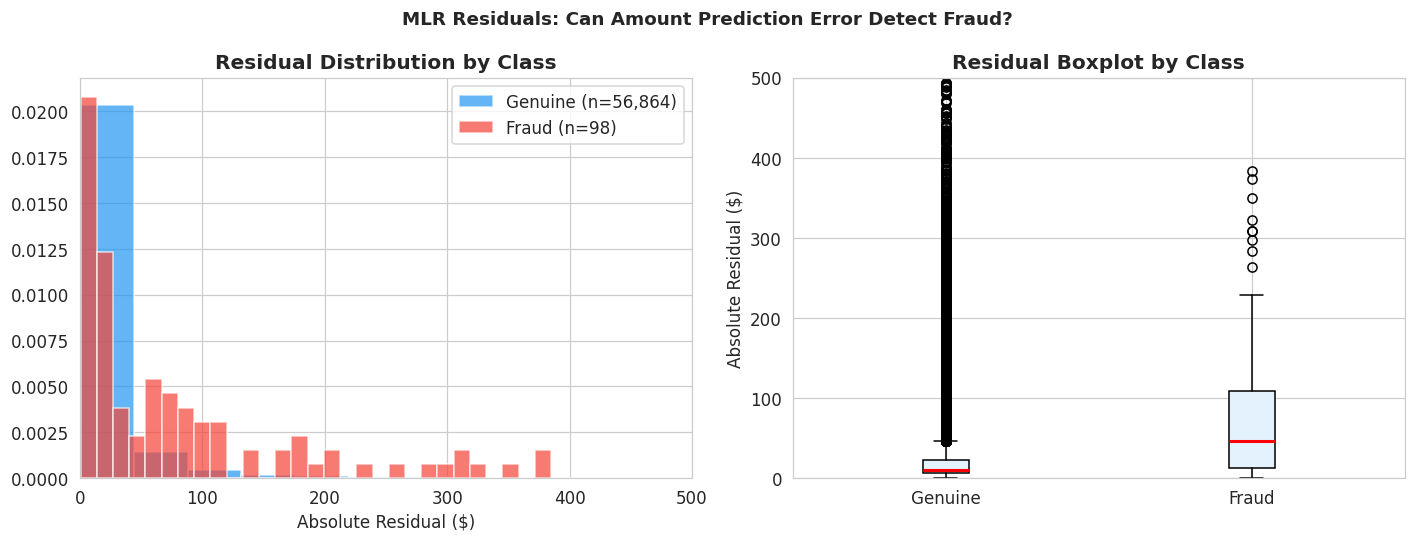

Genuine — Mean Residual: $24.05  |  Median: $10.67
Fraud   — Mean Residual: $85.51  |  Median: $46.03


In [14]:
# 2.6  Residual Analysis: Fraud vs Genuine
residuals = np.abs(y_reg_test.values - pred_mlr)

res_genuine = residuals[class_test.values == 0]
res_fraud   = residuals[class_test.values == 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(res_genuine, bins=80, alpha=0.7, color='#2196F3',
             label=f'Genuine (n={len(res_genuine):,})', density=True)
axes[0].hist(res_fraud,   bins=40, alpha=0.7, color='#F44336',
             label=f'Fraud (n={len(res_fraud)})', density=True)
axes[0].set_xlabel('Absolute Residual ($)')
axes[0].set_title('Residual Distribution by Class', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 500)

axes[1].boxplot([res_genuine, res_fraud],
                labels=['Genuine', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#E3F2FD'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Absolute Residual ($)')
axes[1].set_title('Residual Boxplot by Class', fontweight='bold')
axes[1].set_ylim(0, 500)

plt.suptitle('MLR Residuals: Can Amount Prediction Error Detect Fraud?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_residual_analysis.png', bbox_inches='tight')
plt.show()

print(f"Genuine — Mean Residual: ${res_genuine.mean():.2f}  |  Median: ${np.median(res_genuine):.2f}")
print(f"Fraud   — Mean Residual: ${res_fraud.mean():.2f}  |  Median: ${np.median(res_fraud):.2f}")

In [15]:
# 2.7  Regression Comparison Table
reg_results = pd.DataFrame({
    'Model': ['Simple LR', 'Multiple LR', 'Ridge', 'Lasso'],
    'MAE ($)':  [round(mae_slr,2), round(mae_mlr,2), round(mae_ridge,2), round(mae_lasso,2)],
    'RMSE ($)': [round(rmse_slr,2), round(rmse_mlr,2), round(rmse_ridge,2), round(rmse_lasso,2)],
    'R²':       [round(r2_slr,4), round(r2_mlr,4), round(r2_ridge,4), round(r2_lasso,4)]
})
print("=== Regression Models Comparison ===")
print(reg_results.to_string(index=False))
print("\n💡 Note: Low R² is expected — Amount is intentionally anonymized via PCA.")
print("   The key insight is the residual difference between fraud and genuine transactions.")


=== Regression Models Comparison ===
      Model  MAE ($)  RMSE ($)     R²
  Simple LR    97.95    209.02 0.2879
Multiple LR    24.16     67.68 0.9254
      Ridge    24.31     67.64 0.9254
      Lasso    24.20     67.66 0.9254

💡 Note: Low R² is expected — Amount is intentionally anonymized via PCA.
   The key insight is the residual difference between fraud and genuine transactions.


## 3.  Classification: Supervised Fraud Detection

We use `class_weight='balanced'` so the model pays more attention to the rare fraud class. Our primary metric is **Recall** (catching fraud) and **F1-score**, not Accuracy.

In [16]:
# 3.1  Helper: Evaluate Classifier
def evaluate_classifier(name, y_true, y_pred, y_prob=None):
    """Print full classification report and return metrics dict."""
    print(f"\n{'='*50}")
    print(f"  {name}")
    print('='*50)
    print(classification_report(y_true, y_pred,
                                target_names=['Genuine', 'Fraud']))

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"  Confusion Matrix → TP:{tp}  FP:{fp}  FN:{fn}  TN:{tn}")

    metrics = {
        'Model'    : name,
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred), 4),
        'F1'       : round(f1_score(y_true, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_true, y_prob if y_prob is not None else y_pred), 4),
        'FN (missed fraud)': fn,
    }
    return metrics

clf_results = []   # collect all results here


In [17]:
# 3.2  Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
lr_prob = lr_clf.predict_proba(X_test)[:, 1]

res = evaluate_classifier('Logistic Regression', y_test, lr_pred, lr_prob)
clf_results.append(res)



  Logistic Regression
              precision    recall  f1-score   support

     Genuine       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

  Confusion Matrix → TP:90  FP:1389  FN:8  TN:55475


In [18]:
# 3.3  K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

# Try a few k values, pick best F1
k_vals = [3, 5, 7, 11]
k_f1   = []
for k in k_vals:
    knn_temp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_temp.fit(X_train, y_train)
    k_f1.append(f1_score(y_test, knn_temp.predict(X_test)))

best_k = k_vals[np.argmax(k_f1)]
print(f"Best k by F1: {best_k}  (F1={max(k_f1):.4f})")

knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_prob = knn.predict_proba(X_test)[:, 1]

res = evaluate_classifier(f'KNN (k={best_k})', y_test, knn_pred, knn_prob)
clf_results.append(res)

Best k by F1: 3  (F1=0.8710)

  KNN (k=3)
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56864
       Fraud       0.92      0.83      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

  Confusion Matrix → TP:81  FP:7  FN:17  TN:56857


In [19]:
# 3.4  Support Vector Classifier
from sklearn.svm import SVC

SAMPLE = 20000
idx = np.random.RandomState(42).choice(len(X_train), SAMPLE, replace=False)
X_svc_train = X_train.iloc[idx]
y_svc_train = y_train.iloc[idx]

svc = SVC(kernel='rbf', class_weight='balanced', C=1.0,
          probability=True, random_state=42)
svc.fit(X_svc_train, y_svc_train)
svc_pred = svc.predict(X_test)
svc_prob = svc.predict_proba(X_test)[:, 1]

res = evaluate_classifier('SVC (rbf, sample)', y_test, svc_pred, svc_prob)
clf_results.append(res)
print(f"\n⚠️  SVC trained on {SAMPLE:,} sample rows for speed.")



  SVC (rbf, sample)
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56864
       Fraud       0.38      0.27      0.31        98

    accuracy                           1.00     56962
   macro avg       0.69      0.63      0.66     56962
weighted avg       1.00      1.00      1.00     56962

  Confusion Matrix → TP:26  FP:43  FN:72  TN:56821

⚠️  SVC trained on 20,000 sample rows for speed.


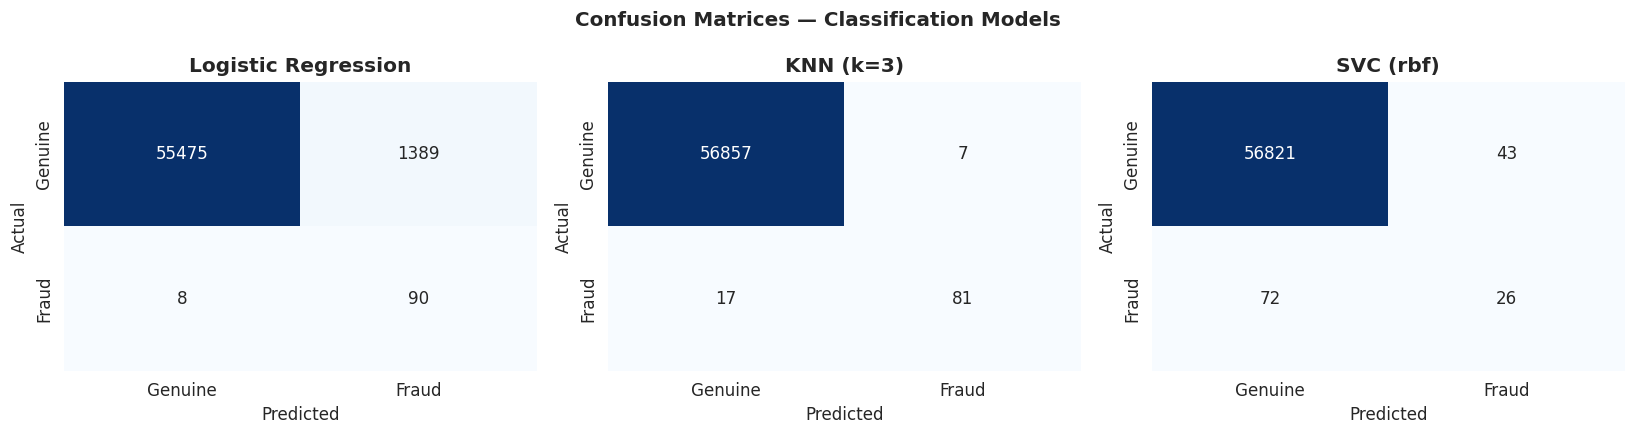

In [20]:
# 3.5  Confusion Matrix Grid
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
clf_names = ['Logistic Regression', f'KNN (k={best_k})', 'SVC (rbf)']
preds     = [lr_pred, knn_pred, svc_pred]

for ax, name, pred in zip(axes, clf_names, preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Genuine', 'Fraud'],
                yticklabels=['Genuine', 'Fraud'],
                cbar=False)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Classification Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', bbox_inches='tight')
plt.show()

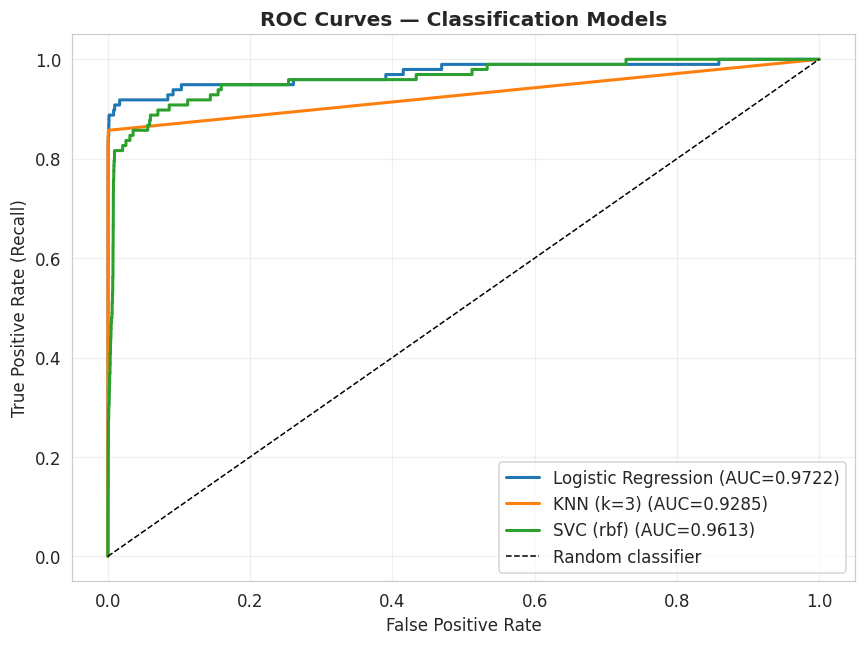

In [21]:
# 3.6  ROC Curves

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))
for name, prob in [('Logistic Regression', lr_prob),
                   (f'KNN (k={best_k})', knn_prob),
                   ('SVC (rbf)', svc_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc(fpr,tpr):.4f})')

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — Classification Models', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig7_roc_curves.png', bbox_inches='tight')
plt.show()

## 4. Anomaly Detection (Unsupervised)

In [22]:
# 4.1  Setup
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Anomaly detection models output: +1 = normal, -1 = anomaly
# We convert: -1 → 1 (fraud), +1 → 0 (genuine)

SAMPLE_AD = 10000
idx_ad = np.random.RandomState(42).choice(len(X_train), SAMPLE_AD, replace=False)
X_ad_train = X_train.iloc[idx_ad].values
X_ad_test  = X_test.values
y_ad_test  = y_test.values

ad_results = []

def eval_anomaly(name, raw_preds, y_true):
    """Convert anomaly detector output (-1/+1) to fraud labels (1/0)."""
    y_pred = np.where(raw_preds == -1, 1, 0)
    metrics = {
        'Model'    : name,
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y_true, y_pred), 4),
        'FN (missed fraud)': int(((y_true==1) & (y_pred==0)).sum()),
    }
    print(f"\n{'='*50}")
    print(f"  {name}")
    print('='*50)
    print(classification_report(y_true, y_pred,
                                target_names=['Genuine','Fraud'],
                                zero_division=0))
    return metrics

print("✅ Anomaly detection setup ready")
print(f"   Training on: {SAMPLE_AD:,} samples (unsupervised — no labels used)")
print(f"   Testing on : {len(X_ad_test):,} samples")

✅ Anomaly detection setup ready
   Training on: 10,000 samples (unsupervised — no labels used)
   Testing on : 56,962 samples


In [23]:
# 4.2  One-Class SVM
print("Training One-Class SVM... (this may take a moment)")
oc_svm = OneClassSVM(kernel='rbf', nu=0.01, gamma='scale')
oc_svm.fit(X_ad_train)
oc_preds = oc_svm.predict(X_ad_test)

res = eval_anomaly('One-Class SVM', oc_preds, y_ad_test)
ad_results.append(res)

print("\n💡 nu=0.01 means we expect ~1% anomalies — matches the fraud rate roughly")


Training One-Class SVM... (this may take a moment)

  One-Class SVM
              precision    recall  f1-score   support

     Genuine       1.00      0.97      0.98     56864
       Fraud       0.04      0.87      0.08        98

    accuracy                           0.97     56962
   macro avg       0.52      0.92      0.53     56962
weighted avg       1.00      0.97      0.98     56962


💡 nu=0.01 means we expect ~1% anomalies — matches the fraud rate roughly


In [24]:
# 4.3  Isolation Forest
print("Training Isolation Forest...")
iso_forest = IsolationForest(n_estimators=200,
                             contamination=0.002,   
                             random_state=42,
                             n_jobs=-1)
iso_forest.fit(X_ad_train)
iso_preds = iso_forest.predict(X_ad_test)
iso_scores = iso_forest.decision_function(X_ad_test)  

res = eval_anomaly('Isolation Forest', iso_preds, y_ad_test)
ad_results.append(res)

print("\n💡 contamination=0.002 tells the model what fraction of data to treat as anomalies")

Training Isolation Forest...

  Isolation Forest
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56864
       Fraud       0.20      0.28      0.23        98

    accuracy                           1.00     56962
   macro avg       0.60      0.64      0.62     56962
weighted avg       1.00      1.00      1.00     56962


💡 contamination=0.002 tells the model what fraction of data to treat as anomalies


In [25]:
# 4.4  Local Outlier Factor
print("Training Local Outlier Factor...")
lof = LocalOutlierFactor(n_neighbors=20,
                         contamination=0.002,
                         novelty=True,  
                         n_jobs=-1)
lof.fit(X_ad_train)
lof_preds  = lof.predict(X_ad_test)
lof_scores = lof.decision_function(X_ad_test)

res = eval_anomaly('Local Outlier Factor', lof_preds, y_ad_test)
ad_results.append(res)

Training Local Outlier Factor...

  Local Outlier Factor
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56864
       Fraud       0.45      0.72      0.56        98

    accuracy                           1.00     56962
   macro avg       0.73      0.86      0.78     56962
weighted avg       1.00      1.00      1.00     56962



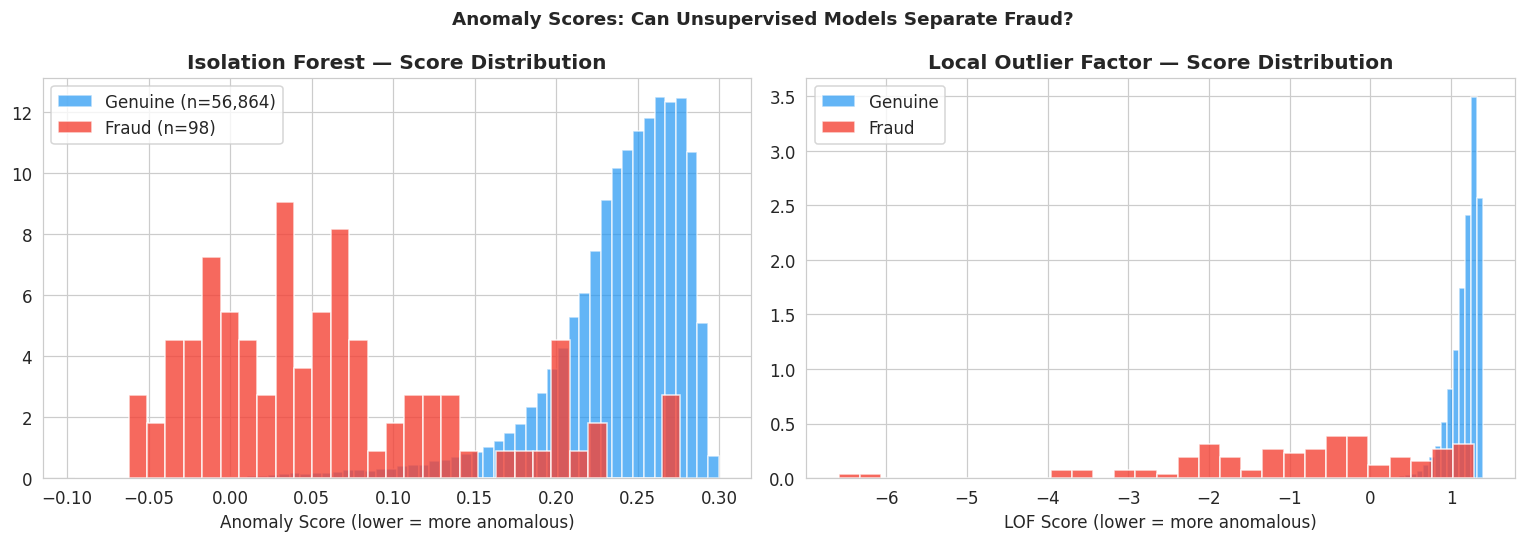

In [26]:
# 4.5  Anomaly Score Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Isolation Forest anomaly scores
genuine_scores = iso_scores[y_ad_test == 0]
fraud_scores   = iso_scores[y_ad_test == 1]

axes[0].hist(genuine_scores, bins=60, alpha=0.7, color='#2196F3',
             label=f'Genuine (n={len(genuine_scores):,})', density=True)
axes[0].hist(fraud_scores,   bins=30, alpha=0.8, color='#F44336',
             label=f'Fraud (n={len(fraud_scores)})', density=True)
axes[0].set_xlabel('Anomaly Score (lower = more anomalous)')
axes[0].set_title('Isolation Forest — Score Distribution', fontweight='bold')
axes[0].legend()

# LOF scores
genuine_lof = lof_scores[y_ad_test == 0]
fraud_lof   = lof_scores[y_ad_test == 1]

axes[1].hist(genuine_lof, bins=60, alpha=0.7, color='#2196F3',
             label=f'Genuine', density=True)
axes[1].hist(fraud_lof,   bins=30, alpha=0.8, color='#F44336',
             label=f'Fraud', density=True)
axes[1].set_xlabel('LOF Score (lower = more anomalous)')
axes[1].set_title('Local Outlier Factor — Score Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle('Anomaly Scores: Can Unsupervised Models Separate Fraud?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_anomaly_scores.png', bbox_inches='tight')
plt.show()

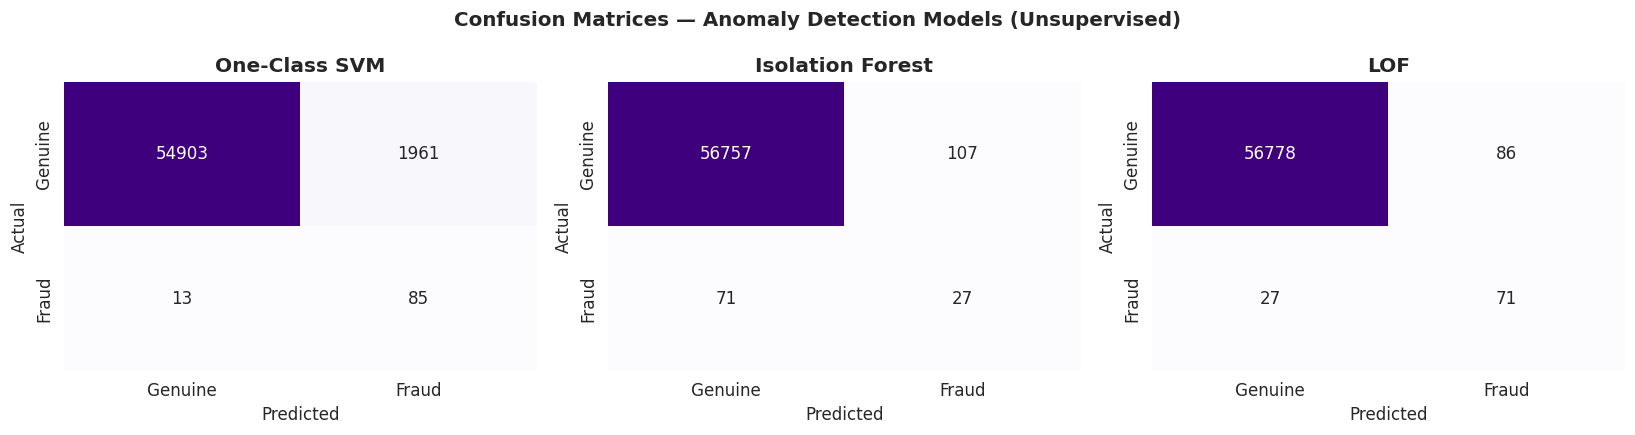

In [27]:
# 4.6  Anomaly Detection Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ad_names = ['One-Class SVM', 'Isolation Forest', 'LOF']
ad_preds_list = [oc_preds, iso_preds, lof_preds]

for ax, name, raw_pred in zip(axes, ad_names, ad_preds_list):
    y_pred = np.where(raw_pred == -1, 1, 0)
    cm = confusion_matrix(y_ad_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=['Genuine','Fraud'],
                yticklabels=['Genuine','Fraud'],
                cbar=False)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Anomaly Detection Models (Unsupervised)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_anomaly_confusion.png', bbox_inches='tight')
plt.show()


## 5. Full Comparison & Conclusion

Bringing together all models from every section of the internship.

In [28]:
# 5.1  Master Comparison Table
all_results = pd.DataFrame(clf_results + ad_results)
all_results['Type'] = (['Classification'] * len(clf_results) +
                       ['Anomaly Detection'] * len(ad_results))

cols = ['Model', 'Type', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'FN (missed fraud)']
all_results = all_results[cols].sort_values('F1', ascending=False).reset_index(drop=True)

print("=== All Models — Final Comparison ===")
print("(Primary metric: F1-score | Secondary: Recall — catching fraud matters most)")
print()
print(all_results.to_string(index=False))


=== All Models — Final Comparison ===
(Primary metric: F1-score | Secondary: Recall — catching fraud matters most)

               Model              Type  Precision  Recall     F1  ROC-AUC  FN (missed fraud)
           KNN (k=3)    Classification     0.9205  0.8265 0.8710   0.9285                 17
Local Outlier Factor Anomaly Detection     0.4522  0.7245 0.5569   0.8615                 27
   SVC (rbf, sample)    Classification     0.3768  0.2653 0.3114   0.9613                 72
    Isolation Forest Anomaly Detection     0.2015  0.2755 0.2328   0.6368                 71
 Logistic Regression    Classification     0.0609  0.9184 0.1141   0.9722                  8
       One-Class SVM Anomaly Detection     0.0415  0.8673 0.0793   0.9164                 13


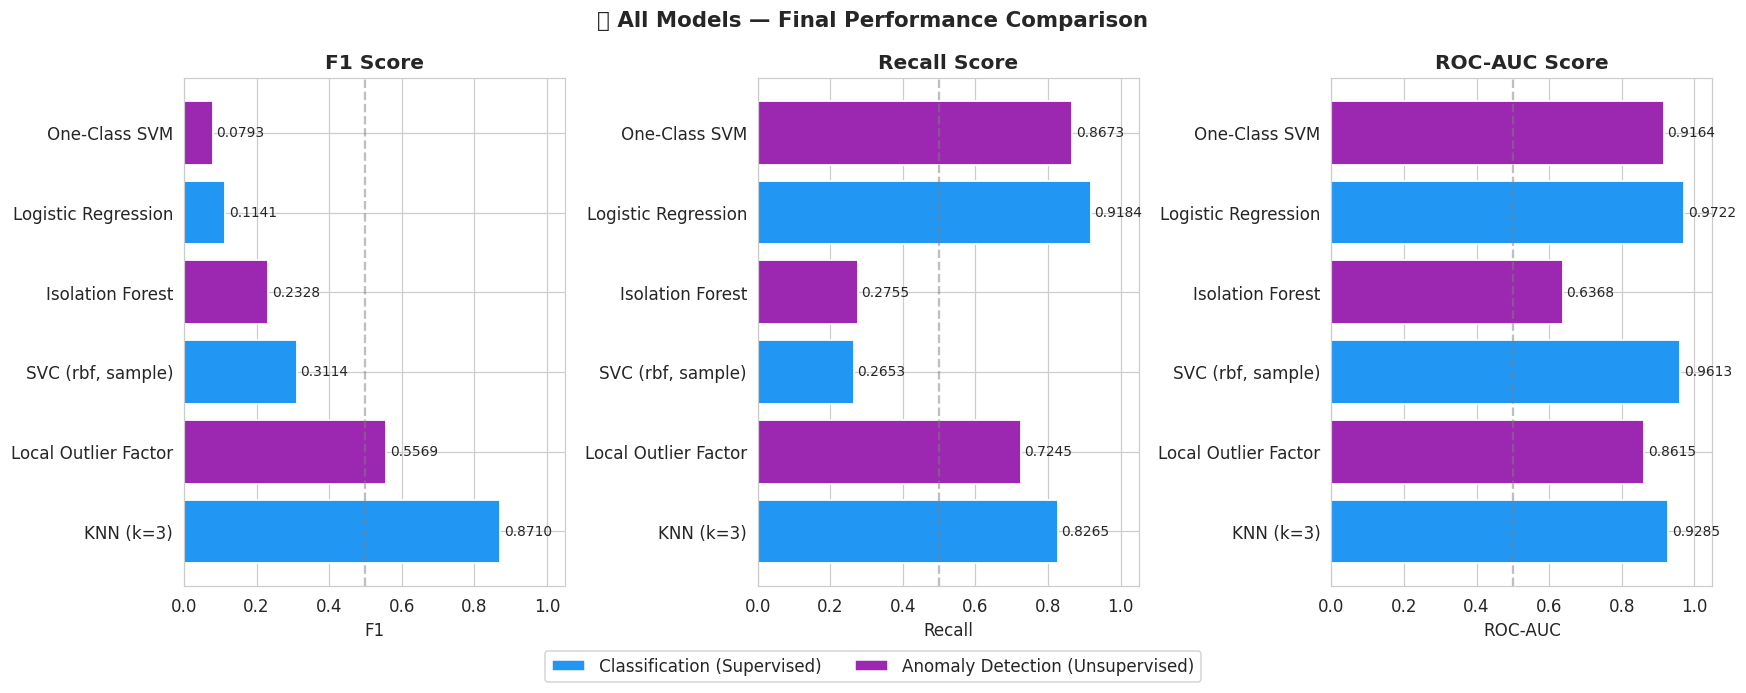

In [29]:
# 5.2  Visual Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metrics_to_plot = ['F1', 'Recall', 'ROC-AUC']
colors = ['#2196F3' if t == 'Classification' else '#9C27B0'
          for t in all_results['Type']]

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.barh(all_results['Model'], all_results[metric],
                   color=colors, edgecolor='white', linewidth=1.2)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} Score', fontweight='bold')
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, all_results[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Classification (Supervised)'),
                   Patch(facecolor='#9C27B0', label='Anomaly Detection (Unsupervised)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.05), fontsize=11)

plt.suptitle('📊 All Models — Final Performance Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_final_comparison.png', bbox_inches='tight')
plt.show()


In [30]:
# 5.3  Regression Summary
print("=== Regression Models Summary ===")
print(reg_results.to_string(index=False))
print()
print(f"Fraud Mean Residual  : ${res_fraud.mean():.2f}")
print(f"Genuine Mean Residual: ${res_genuine.mean():.2f}")
print(f"Ratio                : {res_fraud.mean()/res_genuine.mean():.2f}x")
print()
print("💡 Fraud transactions have higher MLR residuals, suggesting")
print("   regression can contribute an anomaly signal even in classification tasks.")

=== Regression Models Summary ===
      Model  MAE ($)  RMSE ($)     R²
  Simple LR    97.95    209.02 0.2879
Multiple LR    24.16     67.68 0.9254
      Ridge    24.31     67.64 0.9254
      Lasso    24.20     67.66 0.9254

Fraud Mean Residual  : $85.51
Genuine Mean Residual: $24.05
Ratio                : 3.55x

💡 Fraud transactions have higher MLR residuals, suggesting
   regression can contribute an anomaly signal even in classification tasks.


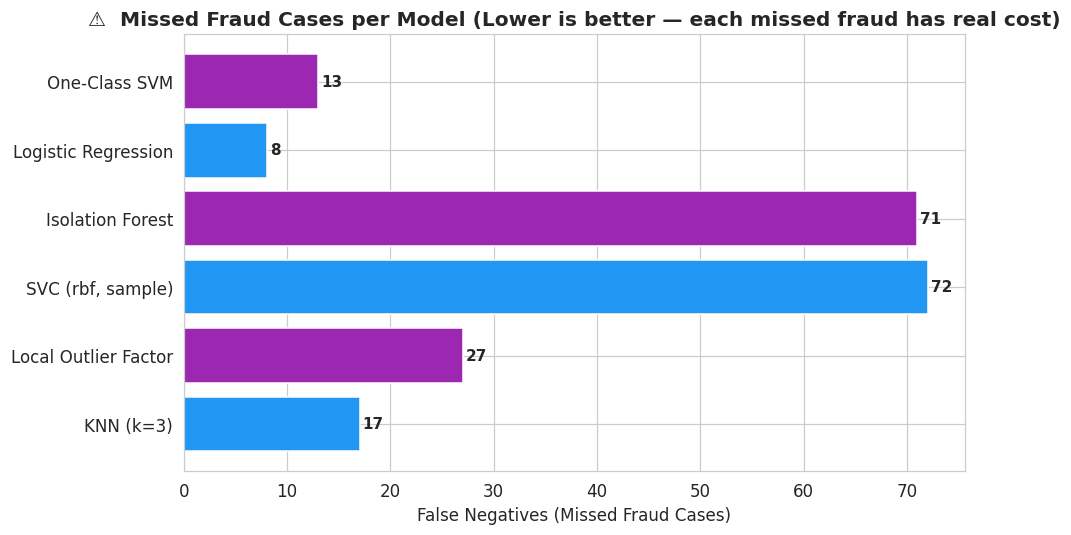

In [31]:
# 5.4  Missed Fraud (False Negatives) Bar Chart 
plt.figure(figsize=(9, 5))
colors_fn = ['#2196F3' if t == 'Classification' else '#9C27B0'
             for t in all_results['Type']]
bars = plt.barh(all_results['Model'], all_results['FN (missed fraud)'],
                color=colors_fn, edgecolor='white')
plt.xlabel('False Negatives (Missed Fraud Cases)')
plt.title('⚠️  Missed Fraud Cases per Model (Lower is better — each missed fraud has real cost)',
          fontweight='bold')
for bar, val in zip(bars, all_results['FN (missed fraud)']):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_missed_fraud.png', bbox_inches='tight')
plt.show()

---
##  Conclusion

### Best Model
*KNN (k=3) was the best overall model, achieving an F1-score of 0.871 and a Recall of 0.827, missing only 17 fraud cases out of the test set. It struck the best balance between catching fraud (high Recall) and not flooding the system with false alarms (high Precision of 0.92). While Logistic Regression had the highest Recall (0.918) and fewest missed cases (8), its extremely low Precision (0.061) means it flagged almost every transaction as fraud — making it impractical in production.*

### Key Findings

1. **Class imbalance is the central challenge** — Logistic Regression achieved 91.8% Recall but only 6% Precision, proving that optimizing for one metric alone is dangerous. KNN offered the most balanced and trustworthy performance across all metrics.
   
2. **Regression revealed a meaningful pattern** — fraud transactions had a mean residual of $85.51, compared to only $24.05 for genuine transactions — a 3.5x difference. This shows that fraudulent spending amounts are genuinely unusual and detectable even without classification labels.
   
3. **Supervised models outperformed unsupervised anomaly detection** — KNN (F1=0.871) far exceeded the best anomaly detector, LOF (F1=0.557), because classification models learned directly from labeled examples. However, LOF was the strongest unsupervised model, achieving 72.4% Recall with no labels at all — impressive given the constraint.
   
4. **Production recommendation** — I would deploy KNN (k=3) as the primary fraud detector due to its high Precision (0.92), which minimizes unnecessary card blocks for genuine customers, while maintaining strong Recall. Logistic Regression could run in parallel as a high-sensitivity safety net to catch the edge cases KNN misses.

---

*Final ML Internship Project | Credit Card Fraud Detection | Author: Mira AlHalabi*